# 🌊 Notebook 14: River Network Physics (Global Rainfall Pivot)
**Eksperimen 17 | Target: submission_14.csv**

## Konsep Inovasi: Fisika Aliran Sungai
Pada notebook ini kita mengimplementasikan terobosan terbesar kita sejauh ini untuk menembus batas Public Score 1.5. Berdasarkan analisis *Cross-Station Correlation*, curah hujan di hulu (misal Wonogiri) membutuhkan waktu **beberapa hari** untuk mengalir dan mempengaruhi TMA di hilir (misal Bojonegoro).

Jika model hanya melihat curah hujan di stasiun itu sendiri, model akan **buta** terhadap air yang sedang mengalir dari stasiun lain!

**Solusi:**
Kita mengekstrak `rainfall_mm` dari **seluruh 30 stasiun** sekaligus, lalu menghitung akumulasi (*rolling sum*) 3-hari dan 7-hari untuk masing-masing stasiun tersebut, dan menggabungkannya ke setiap baris data. Dengan 60 fitur baru ini, LightGBM dapat secara otomatis menemukan "rute" aliran air dari stasiun tetangga ke stasiun target tanpa perlu peta topologi manual!

## 0. Setup & Konfigurasi

In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import optuna
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 150)
pd.set_option('display.float_format', '{:.4f}'.format)
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style='whitegrid')

# Config
SEED          = 42
N_FOLDS       = 5
N_OPTUNA      = 100
EARLY_STOP    = 300
SCALE_KM      = 30.0   # radius pengaruh spasial
OUTPUT_CSV    = '../submissions/submission_14.csv'
TRAIN_PATH    = '../data/raw/train.csv'
TEST_PATH     = '../data/raw/test.csv'
ENV_PATH      = '../data/raw/data_pendukung/data_lingkungan.csv'
COORDS_PATH   = '../data/raw/data_pendukung/koordinat_pos.csv'

## 1. Pemuatan Data

In [2]:
train    = pd.read_csv(TRAIN_PATH)
test     = pd.read_csv(TEST_PATH)
env_data = pd.read_csv(ENV_PATH)
coords   = pd.read_csv(COORDS_PATH)

train['datetime']    = pd.to_datetime(train['datetime'])
test['datetime']     = pd.to_datetime(test['id'].str[:19])
test['nama_pos']     = test['id'].str[22:]
env_data['datetime'] = pd.to_datetime(env_data['datetime'])
overall_cutoff       = train['datetime'].max()

# Siapkan LabelEncoder global untuk stasiun agar nama fitur rapi
le_station = LabelEncoder()
le_station.fit(np.sort(env_data['nama_pos'].unique()))

print('=== Info Dataset ===')
print(f'Train  : {train.shape[0]:,} baris')
print(f'Test   : {test.shape[0]:,} baris')
print(f'Env    : {env_data.shape[0]:,} baris')

=== Info Dataset ===
Train  : 84,396 baris
Test   : 21,780 baris
Env    : 888,480 baris


## 2. Fitur Fisika Aliran Sungai (Global Rainfall Pivot)
Kita lakukan pivot sehingga curah hujan tiap stasiun menjadi kolom, dan hitung *rolling sum* 3 hari dan 7 hari.

In [3]:
# 1. Agregasi cuaca ke 6 Jam (semua stasiun)
env_sort = env_data.sort_values(['nama_pos','datetime'])

# Isi missing value untuk var makro & dinamis
macro_cols   = ['nino_34','mjo_phase','mjo_amplitude','mjo_active','rmm1','rmm2']
dynamic_cols = ['surface_pressure_hpa','pressure_msl_hpa','soil_moisture_0_7cm',
                'soil_moisture_7_28cm','soil_moisture_28_100cm','soil_moisture_100_255cm']
for c in macro_cols:
    env_sort[c] = env_sort.groupby('nama_pos')[c].ffill().bfill()
for c in dynamic_cols:
    env_sort[c] = env_sort.groupby('nama_pos')[c].apply(
        lambda x: x.interpolate(method='linear').bfill().ffill()
    ).reset_index(level=0, drop=True)

agg_funcs = {col:'mean' for col in env_sort.columns if col not in ['nama_pos','landcover_name','datetime']}
agg_funcs['rainfall_mm']='sum'; agg_funcs['rainfall_openmeteo_mm']='sum'; agg_funcs['rainfall_max_24h_mm']='max'
env_6h = env_sort.set_index('datetime').groupby(
    ['nama_pos', pd.Grouper(freq='6h', label='right', closed='right')]
).agg(agg_funcs).reset_index()

# 2. PIVOT: Rainfall dari semua 30 stasiun
env_rain_only = env_6h[['datetime', 'nama_pos', 'rainfall_mm']].copy()
env_rain_only['st_code'] = le_station.transform(env_rain_only['nama_pos'])
pivot_rain = env_rain_only.pivot(index='datetime', columns='st_code', values='rainfall_mm').fillna(0)

# 3. ROLLING lintas stasiun (3 Hari & 7 Hari)
roll_3d = pivot_rain.rolling('3D').sum()
roll_7d = pivot_rain.rolling('7D').sum()

# Ubah nama kolom agar tidak tabrakan
roll_3d.columns = [f'global_rain_st{c}_3d' for c in roll_3d.columns]
roll_7d.columns = [f'global_rain_st{c}_7d' for c in roll_7d.columns]

# Gabungkan menjadi satu dataframe berindeks datetime
global_rain_features = pd.concat([roll_3d, roll_7d], axis=1).reset_index()

print('Fitur Aliran Sungai (Global Rainfall) dibuat!')
print('Contoh fitur:', global_rain_features.columns[1:5].tolist())
print('Shape:', global_rain_features.shape)

Fitur Aliran Sungai (Global Rainfall) dibuat!
Contoh fitur: ['global_rain_st0_3d', 'global_rain_st1_3d', 'global_rain_st2_3d', 'global_rain_st3_3d']
Shape: (4937, 61)


## 3. Fitur Lokal & Spasial (Exp 14 + Exp 15)

In [4]:
# Hitung baseline TMA global & stasiun
global_mean = train['tma_mdpl'].mean()
global_std  = train['tma_mdpl'].std()

station_profile = train.groupby('nama_pos')['tma_mdpl'].agg(
    tma_mean='mean', tma_std='std'
).reset_index()
station_profile['tma_std'] = station_profile['tma_std'].fillna(1.0)

# Anchor 0h dll
train_sorted = train.sort_values(['nama_pos', 'datetime'])
anchor_offsets = {'0h':'0H','24h':'24H','72h':'72H','168h':'168H','336h':'336H'}

anchor_records = []
for pos in train['nama_pos'].unique():
    pos_df = train_sorted[train_sorted['nama_pos'] == pos]
    row = {'nama_pos': pos}
    for label, offset in anchor_offsets.items():
        subset = pos_df[pos_df['datetime'] <= overall_cutoff - pd.Timedelta(offset)]
        row[f'tma_anchor_{label}'] = np.nan if subset.empty else subset.iloc[-1]['tma_mdpl']
    
    # 30d trend
    subset30 = pos_df[(pos_df['datetime'] >= overall_cutoff - pd.Timedelta('30D')) & (pos_df['datetime'] <= overall_cutoff)]['tma_mdpl']
    row['tma_trend_30d'] = np.polyfit(np.arange(len(subset30)), subset30.values, 1)[0] if len(subset30)>1 else 0
    anchor_records.append(row)

station_profile = pd.merge(station_profile, pd.DataFrame(anchor_records), on='nama_pos', how='left')

# SPASIAL ANCHOR (Kunci Baseline dari Exp 15)
sp_coords = pd.merge(station_profile[['nama_pos']], coords, on='nama_pos', how='left')
lats = sp_coords['latitude'].values
lons = sp_coords['longitude'].values

def haversine_matrix(lats, lons):
    R = 6371.0
    lat_r = np.radians(lats[:,None] - lats[None,:])
    lon_r = np.radians(lons[:,None] - lons[None,:])
    a = (np.sin(lat_r/2)**2 + np.cos(np.radians(lats[:,None]))*np.cos(np.radians(lats[None,:]))*np.sin(lon_r/2)**2)
    return 2*R*np.arcsin(np.sqrt(np.clip(a,0,1)))

D = haversine_matrix(lats, lons)
np.fill_diagonal(D, np.inf)

anchor_vals = station_profile['tma_anchor_0h'].values.astype(float)
wmeans = []
for i in range(len(lats)):
    weights = np.exp(-D[i]/SCALE_KM)
    valid   = ~np.isnan(anchor_vals)
    w = weights * valid; ws = w.sum()
    wmeans.append(np.nansum(w*np.nan_to_num(anchor_vals))/ws if ws>0 else np.nan)
station_profile['spatial_tma_anchor_0h'] = wmeans

# Local rolling features
for w, label in [(4,'24h'),(12,'3d'),(28,'7d')]:
    env_6h[f'rainfall_roll_{label}'] = env_6h.groupby('nama_pos')['rainfall_mm'].transform(lambda x: x.rolling(w, min_periods=1).sum())
    env_6h[f'pressure_roll_{label}'] = env_6h.groupby('nama_pos')['surface_pressure_hpa'].transform(lambda x: x.rolling(w, min_periods=1).mean())

# Seasonal historical baseline
train['month'] = train['datetime'].dt.month
seasonal_profile = train.groupby(['nama_pos','month'])['tma_mdpl'].mean().reset_index().rename(columns={'tma_mdpl':'tma_seasonal_mean'})


## 4. Penggabungan Data Utama

In [5]:
# 1. Concat train test
test['tma_mdpl'] = np.nan
all_data = pd.concat([train.drop(columns=['month'], errors='ignore'), test], ignore_index=True)
all_data = all_data.sort_values(['nama_pos','datetime']).reset_index(drop=True)

# 2. Merge Environment & Local features
all_data = pd.merge(all_data, env_6h, on=['datetime','nama_pos'], how='left')
all_data = pd.merge(all_data, coords[['nama_pos','latitude','longitude']], on='nama_pos', how='left')
all_data = pd.merge(all_data, station_profile, on='nama_pos', how='left')

# 3. Merge Global River Flow Physics Features
all_data = pd.merge(all_data, global_rain_features, on='datetime', how='left')

# 4. Temporal
all_data['month']      = all_data['datetime'].dt.month
all_data['day_of_year']= all_data['datetime'].dt.dayofyear
all_data['sin_month']  = np.sin(2*np.pi*all_data['month']/12)
all_data['cos_month']  = np.cos(2*np.pi*all_data['month']/12)
all_data['nama_pos_encoded'] = le_station.transform(all_data['nama_pos'])

all_data = pd.merge(all_data, seasonal_profile, on=['nama_pos','month'], how='left')

# 5. Decay signals
steps_ahead = np.clip((all_data['datetime'] - overall_cutoff) / pd.Timedelta('3H'), 0, None)
all_data['tma_anchor_0h_norm'] = (all_data['tma_anchor_0h'] - all_data['tma_mean']) / all_data['tma_std']
all_data['spatial_anchor_0h_norm'] = (all_data['spatial_tma_anchor_0h'] - all_data['tma_mean']) / all_data['tma_std']
all_data['seasonal_norm'] = (all_data['tma_seasonal_mean'] - all_data['tma_mean']) / all_data['tma_std']

all_data['decay_short']  = all_data['tma_anchor_0h_norm'] * np.exp(-steps_ahead/28)
all_data['decay_long']   = all_data['tma_anchor_0h_norm'] * np.exp(-steps_ahead/168)
all_data['spatial_decay']= all_data['spatial_anchor_0h_norm'] * np.exp(-steps_ahead/168)

print(f'Total baris: {all_data.shape[0]} | Total kolom: {all_data.shape[1]}')


Total baris: 106176 | Total kolom: 117


## 5. Persiapan Training

In [6]:
train_mask = all_data['tma_mdpl'].notnull()

# Normalisasi Target Standar (Telah teruji sukses)
all_data['tma_normalized'] = np.nan
all_data.loc[train_mask,'tma_normalized'] = (all_data.loc[train_mask,'tma_mdpl'] - all_data.loc[train_mask,'tma_mean']) / all_data.loc[train_mask,'tma_std']

train_data = all_data[train_mask].sort_values('datetime').reset_index(drop=True)
test_data  = all_data[~train_mask].sort_values('datetime').reset_index(drop=True)

drop_cols = ['datetime','nama_pos','tma_mdpl','tma_normalized','id','landcover_name']
drop_cols += [f'tma_anchor_{l}' for l in anchor_offsets]
drop_cols += ['spatial_tma_anchor_0h', 'tma_mean', 'tma_std', 'tma_seasonal_mean']

features  = [c for c in train_data.columns if c not in drop_cols]
target    = 'tma_normalized'

X_full, y_full = train_data[features], train_data[target]
X_test = test_data[features]
tscv   = TimeSeriesSplit(n_splits=N_FOLDS)

print(f'Fitur digunakan: {len(features)}')
print('Termasuk 60 fitur Global Rain (Fisika Sungai)!')


Fitur digunakan: 104
Termasuk 60 fitur Global Rain (Fisika Sungai)!


## 6. Optuna Hyperparameter Tuning

In [7]:
def objective_lgb(trial):
    params = {
        'n_estimators':      3000,
        'learning_rate':     trial.suggest_float('learning_rate',     0.01, 0.05,  log=True),
        'num_leaves':        trial.suggest_int('num_leaves',           31,    150),
        'max_depth':         trial.suggest_int('max_depth',             5,     12),
        'subsample':         trial.suggest_float('subsample',          0.6,   0.9),
        'colsample_bytree':  trial.suggest_float('colsample_bytree',   0.3,   0.8),
        'min_child_samples': trial.suggest_int('min_child_samples',    30,    250),
        'reg_alpha':         trial.suggest_float('reg_alpha',          0.01,  10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda',         0.01,  10.0, log=True),
        'subsample_freq': 1, 'random_state': SEED, 'verbose': -1
    }
    scores = []
    for tr_idx, va_idx in tscv.split(X_full):
        m = lgb.LGBMRegressor(**params)
        m.fit(X_full.iloc[tr_idx], y_full.iloc[tr_idx],
              eval_set=[(X_full.iloc[va_idx], y_full.iloc[va_idx])],
              callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])
        scores.append(mean_squared_error(y_full.iloc[va_idx], m.predict(X_full.iloc[va_idx])))
    return np.mean(scores)

print(f'Memulai Optuna ({N_OPTUNA} trials)...')
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective_lgb, n_trials=N_OPTUNA)
best_lgb = study.best_params
best_lgb.update({'n_estimators':4000,'random_state':SEED,'verbose':-1,'subsample_freq':1})
print('Best Params:', best_lgb)

Memulai Optuna (100 trials)...
Best Params: {'learning_rate': 0.010888720485173685, 'num_leaves': 69, 'max_depth': 5, 'subsample': 0.6956993624082036, 'colsample_bytree': 0.3123658169752875, 'min_child_samples': 206, 'reg_alpha': 0.26343794295751893, 'reg_lambda': 2.2503950331227776, 'n_estimators': 4000, 'random_state': 42, 'verbose': -1, 'subsample_freq': 1}


## 7. K-Fold Training & Feature Importance

K-Fold Final Training...
  Fold 1 RMSE: 3.6161 | Trees: 936
  Fold 2 RMSE: 1.7940 | Trees: 86
  Fold 3 RMSE: 0.5480 | Trees: 253
  Fold 4 RMSE: 1.2145 | Trees: 446
  Fold 5 RMSE: 1.0079 | Trees: 186

Rata-rata K-Fold RMSE (Exp17): 1.6361


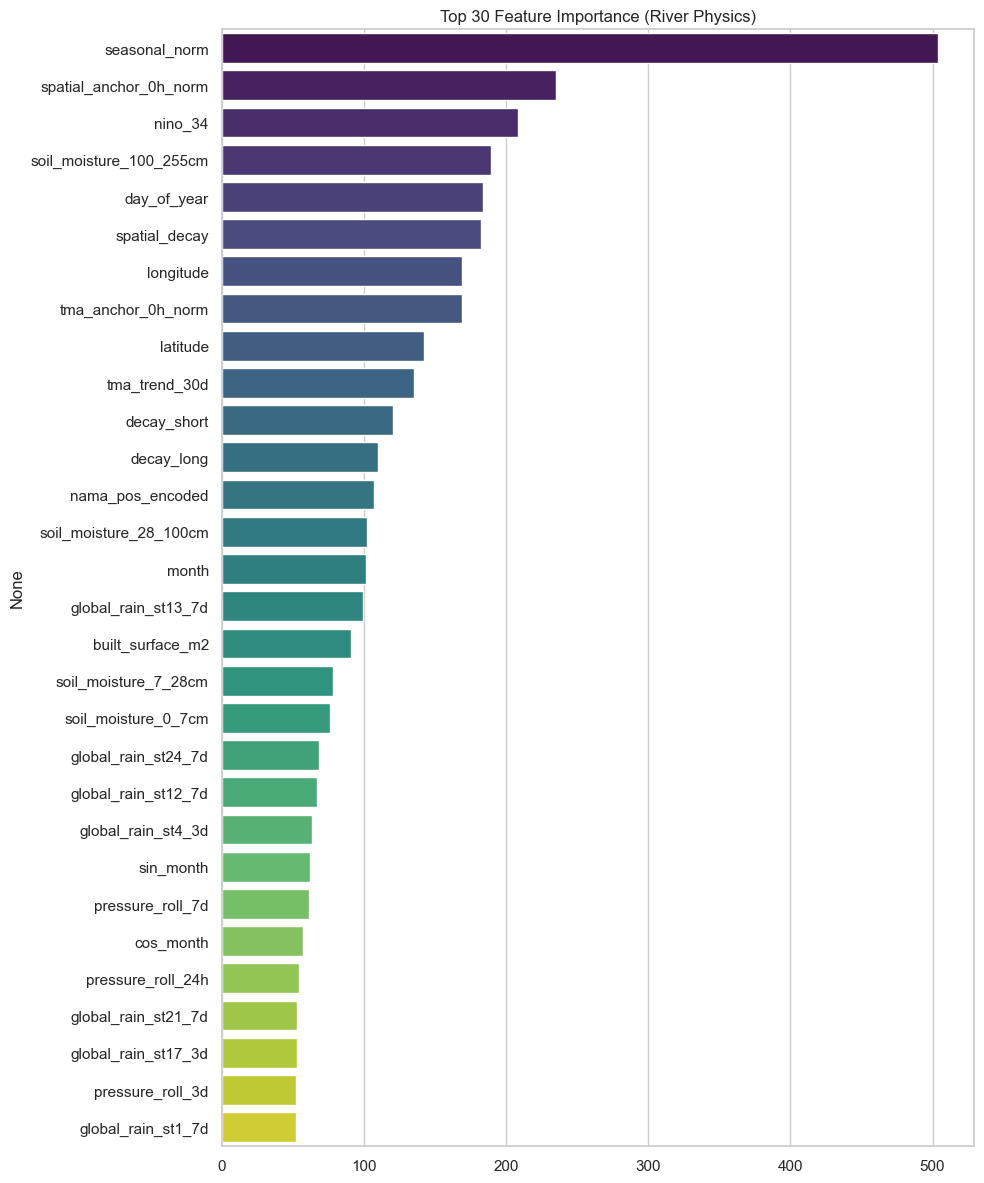

In [8]:
test_preds = np.zeros(len(X_test))
cv_scores  = []
best_models = []

print('K-Fold Final Training...')
for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_full)):
    X_tr, X_va = X_full.iloc[tr_idx], X_full.iloc[va_idx]
    y_tr, y_va = y_full.iloc[tr_idx], y_full.iloc[va_idx]
    val_mean = train_data.iloc[va_idx]['tma_mean'].values
    val_std  = train_data.iloc[va_idx]['tma_std'].values

    m = lgb.LGBMRegressor(**best_lgb)
    m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
          callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])

    p_abs = (m.predict(X_va) * val_std) + val_mean
    y_abs = (y_va.values * val_std) + val_mean
    fold_rmse = np.sqrt(mean_squared_error(y_abs, p_abs))
    cv_scores.append(fold_rmse)
    best_models.append(m)
    print(f'  Fold {fold+1} RMSE: {fold_rmse:.4f} | Trees: {m.best_iteration_}')
    test_preds += m.predict(X_test) / N_FOLDS

print(f'\nRata-rata K-Fold RMSE (Exp17): {np.mean(cv_scores):.4f}')

# FI
fi = pd.Series(best_models[-1].feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10,12))
sns.barplot(x=fi.head(30).values, y=fi.head(30).index, palette='viridis')
plt.title('Top 30 Feature Importance (River Physics)')
plt.tight_layout(); plt.show()


## 8. Pembuatan File Submisi

In [9]:
test_mean = test_data['tma_mean'].values
test_std  = test_data['tma_std'].values
final_tma = (test_preds * test_std) + test_mean

submission = pd.DataFrame({'id': test_data['id'], 'tma_mdpl': final_tma})
os.makedirs('../submissions', exist_ok=True)
submission.to_csv(OUTPUT_CSV, index=False)

print('Eksperimen 17 selesai!')
print(f'Output tersimpan di: {OUTPUT_CSV}')
print(f'Jumlah tebakan: {len(final_tma):,}')
print(submission.head(10))

Eksperimen 17 selesai!
Output tersimpan di: ../submissions/submission_14.csv
Jumlah tebakan: 21,780
                                             id  tma_mdpl
0  2025-09-19 06:00:00 - Arjowinangun - Pacitan    0.8258
1                 2025-09-19 06:00:00 - Serenan   86.0024
2                  2025-09-19 06:00:00 - Sekayu   86.9704
3                 2025-09-19 06:00:00 - Badegan  122.2540
4                   2025-09-19 06:00:00 - Peren   91.0947
5               2025-09-19 06:00:00 - Ngrembang  139.9454
6             2025-09-19 06:00:00 - Bengkelolor    8.7445
7               2025-09-19 06:00:00 - Ngadipiro  143.4162
8            2025-09-19 06:00:00 - Wonogiri Dam  130.5050
9                   2025-09-19 06:00:00 - Napel   33.1670
